# Notbook for Trining with  individual picture embeddings on Mustard

___


In [ ]:
# imports for the dataset module but is is one folder outside the current directory
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import numpy as np
import torch

import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

from torch.utils.data import DataLoader
from torch.utils.data import random_split

import sys
sys.path.append('../../') # parent directory
from dataset import AnglesEncodingDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


In [ ]:
csv_files = ["augmented_mustard_train.csv", "augmented_okra_train.csv" ,"augmented_wheat_train.csv", "augmented_radish_train.csv"]
selected_files = [1,1,1,1] 
root_dir = "../../data"


dataset = AnglesEncodingDataset(root_dir, csv_files, selected_files)
print(f"Number of samples in the dataset: {len(dataset)}\n")


train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
generator = torch.Generator().manual_seed(42)
train_dataset, test_dataset = random_split(dataset, [train_size, test_size], generator=generator)


batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"training set:\t{len(train_loader.dataset)}")
print(f"test set:\t{len(test_loader.dataset)}")


Number of samples in the dataset: 87359

training set:	69887
test set:	17472


## Define Model

In [5]:
class LevelMLP(nn.Module):
    def __init__(self):
        super(LevelMLP, self).__init__()
        # use embedding of images as input
        self.fc1 = nn.Linear(512, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 64)  # Intermediate layer to reduce dimensionality
        self.fc4 = nn.Linear(64, 1)  # Outputs: age (regression), leave_court (regression)

    def forward(self, embedding):
        # embedding shape: (B, 512)
        x = F.relu(self.fc1(embedding))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        out = self.fc4(x)
        level = out[:, 0]         # raw leave court prediction (regression)

        return level 
    

In [ ]:
model = LevelMLP().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 60
mse_loss = nn.MSELoss()

losses = []
eval_losses = []

for epoch in range(num_epochs):
    epoch_loss = []
    for clip_embedding, level, _, class_label, _ in tqdm(train_loader):

        if isinstance(clip_embedding, list):
            clip_embedding = torch.stack(clip_embedding, dim=0)  
            clip_embedding = clip_embedding.mean(dim=0)         
        clip_embedding = clip_embedding.to(device)
        
        if clip_embedding.ndim == 3 and clip_embedding.shape[1] == 1:
            clip_embedding = clip_embedding.squeeze(1)


        target_level = level.to(device)

        level_pred = model(clip_embedding)

        loss_level = mse_loss(level_pred, target_level.float())

        loss = loss_level

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss.append(loss.item())
    losses.append(np.mean(epoch_loss))
    print(f"Epoch: {epoch}, Loss: {losses[-1]}")

# save model
torch.save(model.state_dict(), 'level_model.pth')
print("Model saved as level_model.pth")


  0%|          | 0/1092 [00:00<?, ?it/s]

100%|██████████| 1092/1092 [00:51<00:00, 21.11it/s]


Epoch: 0, Loss: 1.0454656527592585


100%|██████████| 1092/1092 [00:51<00:00, 21.15it/s]


Epoch: 1, Loss: 0.6975844847959477


...

Epoch: 57, Loss: 0.17607391332941397


100%|██████████| 1092/1092 [00:51<00:00, 21.37it/s]


Epoch: 58, Loss: 0.17867898561688134


100%|██████████| 1092/1092 [00:51<00:00, 21.33it/s]

Epoch: 59, Loss: 0.1720111159396259


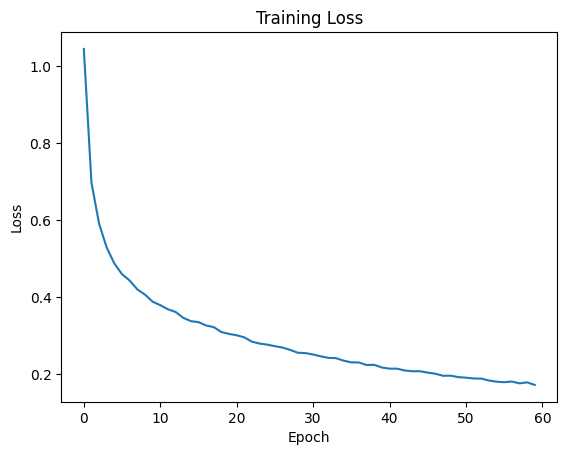

In [29]:
# pllot loss
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

In [9]:
# run the validation set 
# load model
model = LevelMLP().to(device)
model.load_state_dict(torch.load('level_model.pth'))
model.eval()

mse_loss = nn.MSELoss()


#save all predictions for plotting later
level_predictions = []
level_targets = []
eval_losses = []

for clip_embedding, level, _, class_label, _ in tqdm(test_loader):


    if isinstance(clip_embedding, list):
        clip_embedding = torch.stack(clip_embedding, dim=0)  
        clip_embedding = clip_embedding.mean(dim=0)         
    clip_embedding = clip_embedding.to(device)

    if clip_embedding.ndim == 3 and clip_embedding.shape[1] == 1:
        clip_embedding = clip_embedding.squeeze(1)

    # Move targets to device and ensure correct dtype
    target_level = level.to(device, dtype=torch.float32)

    with torch.no_grad():
        level_pred = model(clip_embedding)

    level_pred = torch.round(level_pred * 100) // 100

    level_predictions.extend(level_pred.cpu().numpy())
    level_targets.extend(target_level.cpu().numpy())

    loss_level = mse_loss(level_pred.view(-1), target_level.view(-1))

    loss = loss_level
    eval_losses.append(loss.item())   


print(f"Eval Loss: {np.mean(eval_losses)}")

/tmp/ipykernel_8380/2741182340.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('level_model.pth'))
  0%|          | 0/273 [00:00<?, ?it/

100%|██████████| 273/273 [00:12<00:00, 21.85it/s]

Eval Loss: 0.6464629120879121


In [13]:
# caluclate R2
r2_level = r2_score(level_targets, level_predictions)
print(f"R2 Level: {r2_level}")

# Calculate accuracy
mae_level = mean_absolute_error(level_targets, level_predictions)
print(f"MAE Level: {mae_level}")

#caluclate accuracy thresholded of 1 level
accuracy_level = np.mean(np.array(level_predictions) == np.array(level_targets))
print(f"Accuracy Level: {accuracy_level}")



R2 Level: 0.6784684573811701
MAE Level: 0.5642742673992674
Accuracy Level: 0.4741300366300366


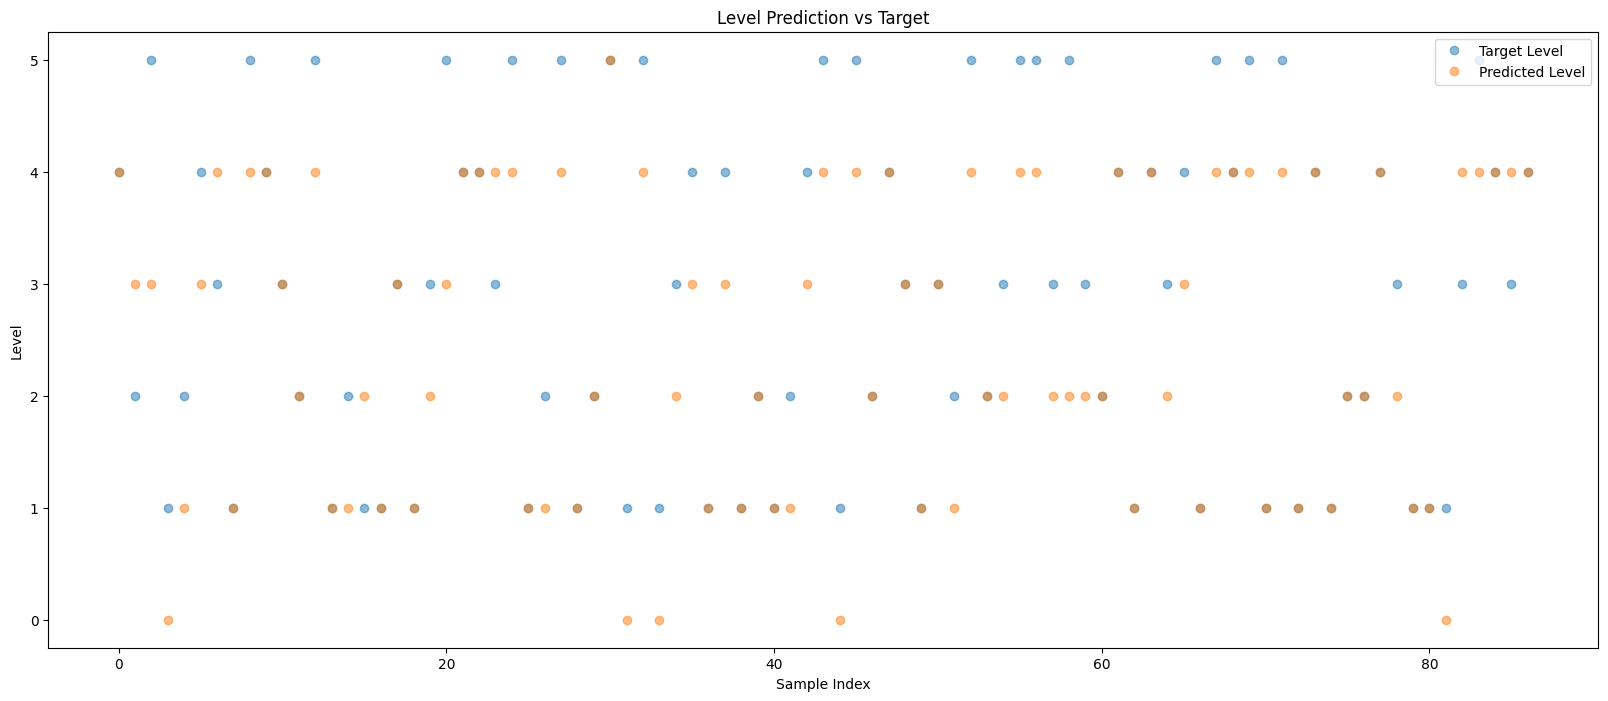

In [11]:
# plot predection like above but with all predictions
plot_range = slice(0, len(test_loader.dataset)//200)  # Adjust this range as needed

plt.figure(figsize=(20, 8))
plt.plot(level_targets[plot_range], 'o', alpha=0.5, label='Target Level')
plt.plot(level_predictions[plot_range], 'o', alpha=0.5, label='Predicted Level')
plt.xlabel('Sample Index')
plt.ylabel('Level')
plt.title('Level Prediction vs Target')
plt.legend()
plt.show()  


In [33]:
# save model
torch.save(model.state_dict(), 'level_model.pth')
print("Model saved as level_model.pth")

Model saved as level_model.pth


In [ ]:
# load model
model = LevelMLP().to(device)
model.load_state_dict(torch.load('level_model.pth'))
model.eval()